In [1]:
import pandas as pd

classification_df = pd.read_csv('data/diabetes_three_category.csv')

# show unique values for each column
for col in classification_df.columns:
    print(f"{col}: {classification_df[col].unique()}")

Diabetes_012: [0. 2. 1.]
HighBP: [1. 0.]
HighChol: [1. 0.]
CholCheck: [1. 0.]
BMI: [40. 25. 28. 27. 24. 30. 34. 26. 33. 21. 23. 22. 38. 32. 37. 31. 29. 20.
 35. 45. 39. 19. 47. 18. 36. 43. 55. 49. 42. 17. 16. 41. 44. 50. 59. 48.
 52. 46. 54. 57. 53. 14. 15. 51. 58. 63. 61. 56. 74. 62. 64. 66. 73. 85.
 60. 67. 65. 70. 82. 79. 92. 68. 72. 88. 96. 13. 81. 71. 75. 12. 77. 69.
 76. 87. 89. 84. 95. 98. 91. 86. 83. 80. 90. 78.]
Smoker: [1. 0.]
Stroke: [0. 1.]
HeartDiseaseorAttack: [0. 1.]
PhysActivity: [0. 1.]
Fruits: [0. 1.]
Veggies: [1. 0.]
HvyAlcoholConsump: [0. 1.]
AnyHealthcare: [1. 0.]
NoDocbcCost: [0. 1.]
GenHlth: [5. 3. 2. 4. 1.]
MentHlth: [18.  0. 30.  3.  5. 15. 10.  6. 20.  2. 25.  1.  4.  7.  8. 21. 14. 26.
 29. 16. 28. 11. 12. 24. 17. 13. 27. 19. 22.  9. 23.]
PhysHlth: [15.  0. 30.  2. 14. 28.  7. 20.  3. 10.  1.  5. 17.  4. 19.  6. 12. 25.
 27. 21. 22.  8. 29. 24.  9. 16. 18. 23. 13. 26. 11.]
DiffWalk: [1. 0.]
Sex: [0. 1.]
Age: [ 9.  7. 11. 10.  8. 13.  4.  6.  2. 12.  5.  1.  3

In [2]:
binary_df = pd.read_csv('data/diabetes_two_category.csv')
binary_df.head()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [5]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import numpy as np

# prep data 
classification_df = classification_df.sample(frac=1, random_state=42).reset_index(drop=True)
binary_df = binary_df.sample(frac=1, random_state=42).reset_index(drop=True)

# Standard scaling before PCA for classification_df
features_class = classification_df.loc[:, classification_df.columns != 'Diabetes_012']
target_class = classification_df['Diabetes_012']
scaler_class = StandardScaler()
features_class_scaled = scaler_class.fit_transform(features_class)
pca_class = PCA(n_components=10, random_state=42)
features_class_pca = pca_class.fit_transform(features_class_scaled)
classification_df_pca = pd.DataFrame(features_class_pca)
classification_df_pca['Diabetes_012'] = target_class.values

# Standard scaling before PCA for binary_df
features_bin = binary_df.loc[:, binary_df.columns != 'Diabetes_binary']
target_bin = binary_df['Diabetes_binary']
scaler_bin = StandardScaler()
features_bin_scaled = scaler_bin.fit_transform(features_bin)
pca_bin = PCA(n_components=10, random_state=42)
features_bin_pca = pca_bin.fit_transform(features_bin_scaled)
binary_df_pca = pd.DataFrame(features_bin_pca)
binary_df_pca['Diabetes_binary'] = target_bin.values

# set aside 10% of data for part B
bin_train, bin_test = train_test_split(binary_df_pca, test_size=0.1, random_state=42)
class_train, class_test = train_test_split(classification_df_pca, test_size=0.1, random_state=42)

# split into 4 sets
classification_sets = [df.reset_index(drop=True) for df in np.array_split(class_train, 4)]
binary_sets = [df.reset_index(drop=True) for df in np.array_split(bin_train, 4)]

kf = KFold(n_splits=5, shuffle=True, random_state=42)

c_knn_df = classification_sets[2]
b_knn_df = binary_sets[2]

RUN MULTIKNN

In [6]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
import numpy as np

knn_class_accuracies = []   # list of lists: one list of 5 fold accuracies per k
k_values = [5, 10, 15, 20, 25, 30 , 35]

X_all = c_knn_df.loc[:, c_knn_df.columns != 'Diabetes_012']
y_all = c_knn_df['Diabetes_012']

for value in k_values:
    accuracies_list = []
    print(f"\n===== n_neighbors = {value} =====")

    for i, (train, test) in enumerate(kf.split(X_all, y_all)):
        print(f"\nFold {i+1}")
        print("TRAIN indices:", train)
        print("TEST indices:", test)

        X_train = X_all.loc[train]
        y_train = y_all.loc[train]

        X_test = X_all.loc[test]
        y_test = y_all.loc[test]

        # scale inside each fold
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        knn_classifier = KNeighborsClassifier(n_neighbors=value)
        knn_classifier.fit(X_train_scaled, y_train)
        scores = knn_classifier.score(X_test_scaled, y_test)
        print(f"Accuracy of splits = {value}: {scores}\n")
        accuracies_list.append(scores)
        
    knn_class_accuracies.append(accuracies_list)
    print(f"Mean CV accuracy for k={value}: {np.mean(accuracies_list):.4f}")



===== n_neighbors = 5 =====

Fold 1
TRAIN indices: [    0     1     2 ... 57075 57076 57077]
TEST indices: [    4     6    31 ... 57062 57065 57070]
Accuracy of splits = 5: 0.8353188507358094


Fold 2
TRAIN indices: [    2     3     4 ... 57075 57076 57077]
TEST indices: [    0     1     7 ... 57061 57063 57067]
Accuracy of splits = 5: 0.8313770147161879


Fold 3
TRAIN indices: [    0     1     2 ... 57071 57074 57077]
TEST indices: [    3     8    14 ... 57073 57075 57076]
Accuracy of splits = 5: 0.8255080588647512


Fold 4
TRAIN indices: [    0     1     2 ... 57075 57076 57077]
TEST indices: [    5    15    18 ... 57058 57069 57071]
Accuracy of splits = 5: 0.8364432763907139


Fold 5
TRAIN indices: [    0     1     3 ... 57073 57075 57076]
TEST indices: [    2     9    10 ... 57060 57074 57077]
Accuracy of splits = 5: 0.8348664038545773

Mean CV accuracy for k=5: 0.8327

===== n_neighbors = 10 =====

Fold 1
TRAIN indices: [    0     1     2 ... 57075 57076 57077]
TEST indices: [   

RUN BINARY

In [7]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
import numpy as np

knn_bin_accuracies = []   # list of lists: one list of 5 fold accuracies per k
k_values = [5, 10, 15, 20, 25, 30, 35]

X_all = b_knn_df.loc[:, b_knn_df.columns != 'Diabetes_binary']
y_all = b_knn_df['Diabetes_binary']

for value in k_values:
    accuracies_list = []
    print(f"\n===== n_neighbors = {value} =====")

    for i, (train, test) in enumerate(kf.split(X_all, y_all)):
        print(f"\nFold {i+1}")
        print("TRAIN indices:", train)
        print("TEST indices:", test)

        X_train = X_all.loc[train]
        y_train = y_all.loc[train]

        X_test = X_all.loc[test]
        y_test = y_all.loc[test]

        # scale inside each fold
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        knn_classifier = KNeighborsClassifier(n_neighbors=value)
        knn_classifier.fit(X_train_scaled, y_train)
        scores = knn_classifier.score(X_test_scaled, y_test)
        print(f"Accuracy of splits = {value}: {scores}\n")
        accuracies_list.append(scores)
        
    knn_bin_accuracies.append(accuracies_list)
    print(f"Mean CV accuracy for k={value}: {np.mean(accuracies_list):.4f}")



===== n_neighbors = 5 =====

Fold 1
TRAIN indices: [    0     1     2 ... 57075 57076 57077]
TEST indices: [    4     6    31 ... 57062 57065 57070]
Accuracy of splits = 5: 0.8527505255781359


Fold 2
TRAIN indices: [    2     3     4 ... 57075 57076 57077]
TEST indices: [    0     1     7 ... 57061 57063 57067]
Accuracy of splits = 5: 0.850385423966363


Fold 3
TRAIN indices: [    0     1     2 ... 57071 57074 57077]
TEST indices: [    3     8    14 ... 57073 57075 57076]
Accuracy of splits = 5: 0.8405746320953048


Fold 4
TRAIN indices: [    0     1     2 ... 57075 57076 57077]
TEST indices: [    5    15    18 ... 57058 57069 57071]
Accuracy of splits = 5: 0.8535260621988612


Fold 5
TRAIN indices: [    0     1     3 ... 57073 57075 57076]
TEST indices: [    2     9    10 ... 57060 57074 57077]
Accuracy of splits = 5: 0.8493210687691634

Mean CV accuracy for k=5: 0.8493

===== n_neighbors = 10 =====

Fold 1
TRAIN indices: [    0     1     2 ... 57075 57076 57077]
TEST indices: [    

Plot K_FOLD MULTI

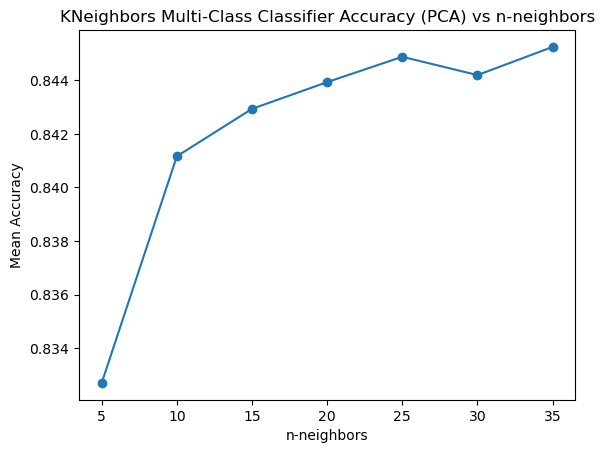

In [8]:
import matplotlib.pyplot as plt

# process results and plot
knn_class_mean_accuracies = [np.mean(acc) for acc in knn_class_accuracies]

plt.plot(k_values, knn_class_mean_accuracies, marker='o')
plt.title('KNeighbors Multi-Class Classifier Accuracy (PCA) vs n-neighbors')
plt.xlabel('n-neighbors')
plt.ylabel('Mean Accuracy')
plt.show()

PLOT BINARY

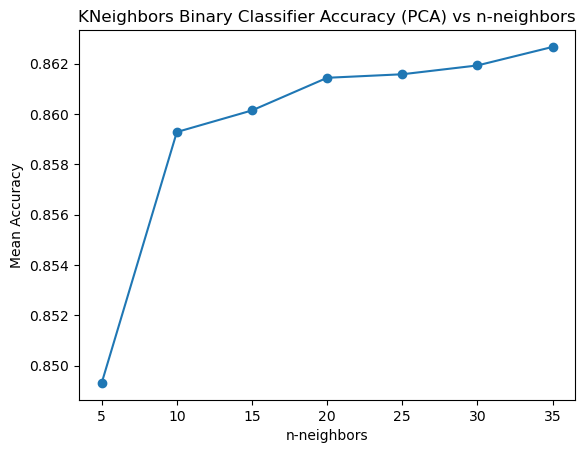

In [9]:
import matplotlib.pyplot as plt

# process results and plot
knn_bin_mean_accuracies = [np.mean(acc) for acc in knn_bin_accuracies]

plt.plot(k_values, knn_bin_mean_accuracies, marker='o')
plt.title('KNeighbors Binary Classifier Accuracy (PCA) vs n-neighbors')
plt.xlabel('n-neighbors')
plt.ylabel('Mean Accuracy')
plt.show()

### Get final performance and runtime of best binary knn model

In [10]:
# prep data for final training
best_bin_kn_value=35
best_bin_kn_classifier = KNeighborsClassifier(n_neighbors=best_bin_kn_value)

In [11]:
# train and get runtime
best_bin_kn_classifier.fit(bin_train.loc[:, bin_train.columns != 'Diabetes_binary'], bin_train['Diabetes_binary'])

KNeighborsClassifier(n_neighbors=35)

In [12]:
best_bin_kn_classifier.score(
    bin_train.loc[:, bin_train.columns != 'Diabetes_binary'].to_numpy(),
    bin_train['Diabetes_binary'].to_numpy()
)

0.8681146851676653

In [13]:
# best_bin_kn_classifier.score(bin_test.loc[:, bin_test.columns != 'Diabetes_binary'], bin_test['Diabetes_binary'])
best_bin_kn_classifier.score(
    bin_test.loc[:, bin_test.columns != 'Diabetes_binary'].to_numpy(),
    bin_test['Diabetes_binary'].to_numpy()
)

0.8628587196467992

### Get final performance and runtime of best class knn model

In [14]:
# prep data for final training
best_class_kn_value=35
best_class_kn_classifier = KNeighborsClassifier(n_neighbors=best_class_kn_value)

In [15]:
# train and get runtime
best_class_kn_classifier.fit(class_train.loc[:, class_train.columns != 'Diabetes_012'], class_train['Diabetes_012'])

KNeighborsClassifier(n_neighbors=35)

In [16]:
best_class_kn_classifier.score(
    class_train.loc[:, class_train.columns != 'Diabetes_012'].to_numpy(),
    class_train['Diabetes_012'].to_numpy()
)

0.8512079960755458

In [17]:
# get testing performance
best_class_kn_classifier.score(
    class_test.loc[:, class_test.columns != 'Diabetes_012'].to_numpy(),
    class_test['Diabetes_012'].to_numpy()
)

0.8460264900662252